imports and setup

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # fallback to CPU for unsupported MPS ops

import sys
import json
sys.stdout.flush()
from pathlib import Path
import pandas as pd
import torch
import torch.nn as nn
import random
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib inline
ROOT_DIR = Path(".") / "confirmed_fronts"
OUT_DIR = Path(".") / "output"
OUT_DIR.mkdir(exist_ok=True)

loading data from the confirmed_fronts dataset

In [2]:
def parse_color_from_filename(filename: str) -> str | None:
    parts = filename.split("$$")
    if len(parts) < 4:
        return None
    return parts[3].strip().lower()
def make_dataframe(root_dir=None):
    root = Path(root_dir) if root_dir else ROOT_DIR
    rows = []
    for p in tqdm(list(root.rglob("*.jpg")), desc="loading files"):
        color = parse_color_from_filename(p.name)
        if color is None:
            continue
        rows.append({"path": str(p), "color": color})
    return pd.DataFrame(rows)

dataset, transforms and train/val/test split

In [3]:
class CarColorDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        y = int(self.df.loc[idx, "label"])
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, y

def make_datasets():
    df = make_dataframe()
    print(f"total images: {len(df)}")
    print(f"unique colors: {df['color'].nunique()}")
    print(df["color"].value_counts())
    df = df[~df["color"].isin(["unlisted", "multicolour"])].reset_index(drop=True)
    vc = df["color"].value_counts()
    keep_colors = vc[vc >= 200].index
    df = df[df["color"].isin(keep_colors)].reset_index(drop=True)
    print(f"\nafter filtering: {len(df)} images, {df['color'].nunique()} classes")
    print(df["color"].value_counts())
    colors = sorted(df["color"].unique())
    color2idx = {c: i for i, c in enumerate(colors)}
    df["label"] = df["color"].map(color2idx).astype(int)
    train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])
    train_df, val_df = train_test_split(
        train_val_df, test_size=0.125, random_state=42, stratify=train_val_df["label"]
    )
    print(f"\ntrain={len(train_df)}  val={len(val_df)}  test={len(test_df)}  classes={len(colors)}")
    train_tfms = T.Compose([
        T.Resize((256, 256)),
        T.RandomResizedCrop(224, scale=(0.8, 1.0)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
        T.ToTensor(),
        T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])
    eval_tfms = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])
    train_ds = CarColorDataset(train_df, transform=train_tfms)
    val_ds = CarColorDataset(val_df, transform=eval_tfms)
    test_ds = CarColorDataset(test_df, transform=eval_tfms)
    class_counts = train_df["label"].value_counts().sort_index().values
    class_weights = 1.0 / class_counts
    sample_weights = train_df["label"].map(lambda y: class_weights[int(y)]).values
    return colors, sample_weights, train_ds, val_ds, test_ds

mobilenet v1 architecture — from-scratch implementation

In [4]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.depthwise = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU6(inplace=True),
        )
        self.pointwise = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU6(inplace=True),
        )
    def forward(self, x):
        return self.pointwise(self.depthwise(x))

class MobileNetV1(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True),
        )
        cfg = [
            (64, 1),
            (128, 2), (128, 1),
            (256, 2), (256, 1),
            (512, 2),
            (512, 1), (512, 1), (512, 1), (512, 1), (512, 1),
            (1024, 2), (1024, 1),
        ]
        layers, in_ch = [], 32
        for out_ch, s in cfg:
            layers.append(DepthwiseSeparableConv(in_ch, out_ch, stride=s))
            in_ch = out_ch
        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(1024, num_classes)
    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)

pretrained models — resnet18 and efficientnet-b0

In [5]:
def make_pretrained_resnet18(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def make_pretrained_efficientnet_b0(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    return model

training and evaluation functions

In [6]:
import gc

def get_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True

def to_cpu(obj):
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu()
    elif isinstance(obj, dict):
        return {k: to_cpu(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return type(obj)(to_cpu(v) for v in obj)
    return obj

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys, preds = [], []
    for x, y in loader:
        x = x.to(device)
        pred = model(x).argmax(dim=1).cpu()
        ys.append(y)
        preds.append(pred)
    ys = torch.cat(ys).numpy()
    preds = torch.cat(preds).numpy()
    return f1_score(ys, preds, average="macro"), ys, preds

def train_model(model, train_loader, val_loader, device, epochs=10, lr=1e-3, weight_decay=1e-4, save_path=None):
    ckpt_path = save_path.replace("_history.json", "_checkpoint.pth") if save_path else None

    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_f1": [], "val_f1": []}
    best_f1, best_state = -1.0, None
    start_epoch = 1

    if ckpt_path and Path(ckpt_path).exists():
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])
        history = ckpt["history"]
        best_f1 = ckpt["best_f1"]
        best_state = ckpt["best_state"]
        start_epoch = ckpt["epoch"] + 1
        tqdm.write(f"  resumed from epoch {ckpt['epoch']}/{epochs}, best_val_f1={best_f1:.4f}")

    for epoch in tqdm(range(start_epoch, epochs + 1), desc="epochs"):
        model.train()
        running_loss, n = 0.0, 0
        ys_train, preds_train = [], []
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            n += x.size(0)
            ys_train.append(y.cpu())
            preds_train.append(logits.detach().argmax(1).cpu())
        scheduler.step()
        train_loss = running_loss / max(n, 1)
        train_f1 = f1_score(torch.cat(ys_train).numpy(), torch.cat(preds_train).numpy(), average="macro")
        del ys_train, preds_train
        val_f1, _, _ = evaluate(model, val_loader, device)
        # flush MPS queue and free cached buffers before saving
        if device == "mps":
            torch.mps.synchronize()
            torch.mps.empty_cache()
        gc.collect()
        history["train_loss"].append(train_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)
        cur_lr = scheduler.get_last_lr()[0]
        tqdm.write(f"  epoch {epoch:02d}/{epochs} | loss={train_loss:.4f} | train_f1={train_f1:.4f} | val_f1={val_f1:.4f} | lr={cur_lr:.2e}")
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if ckpt_path:
            torch.save({
                "epoch": epoch,
                "model_state": to_cpu(model.state_dict()),
                "optimizer_state": to_cpu(optimizer.state_dict()),
                "scheduler_state": scheduler.state_dict(),
                "history": history,
                "best_f1": best_f1,
                "best_state": best_state,
            }, ckpt_path)

    model.load_state_dict(best_state)
    if save_path:
        with open(save_path, "w") as f:
            json.dump(history, f)
    return model, best_f1, history

def load_or_train(model, train_loader, val_loader, device, *, save_path, **kwargs):
    ckpt_path = save_path.replace("_history.json", "_checkpoint.pth")
    epochs = kwargs.get("epochs", 10)
    if Path(save_path).exists() and Path(ckpt_path).exists():
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        if ckpt["epoch"] >= epochs:
            print(f"training complete — loading best weights from {ckpt_path}")
            model.load_state_dict(ckpt["best_state"])
            model.to(device)
            return model, ckpt["best_f1"], ckpt["history"]
    return train_model(model, train_loader, val_loader, device, save_path=save_path, **kwargs)

visualization functions

In [7]:
def plot_training_curves(history: dict, name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, history["train_loss"], marker="o")
    ax1.set_title(f"{name} — train loss")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("crossentropy loss")
    ax1.grid(True)
    ax2.plot(epochs, history["train_f1"], marker="o", label="train")
    ax2.plot(epochs, history["val_f1"], marker="o", color="orange", label="val")
    ax2.set_title(f"{name} — f1_macro")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("f1_macro")
    ax2.set_ylim(0, 1); ax2.grid(True)
    ax2.legend()
    fig.tight_layout()
    path = OUT_DIR / f"curves_{name}.png"
    fig.savefig(path, dpi=120)
    plt.show()
    print(f"  -> {path}")

def plot_confusion_matrix(ys, preds, class_names: list, name):
    cm = confusion_matrix(ys, preds, normalize="true")
    fig, ax = plt.subplots(figsize=(max(6, len(class_names)), max(5, len(class_names) - 1)))
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    fig.colorbar(im, ax=ax)
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{name} — confusion matrix (test, normalized)")
    fig.tight_layout()
    path = OUT_DIR / f"cm_{name}.png"
    fig.savefig(path, dpi=120)
    plt.show()
    print(f"  -> {path}")

def save_classification_report(ys, preds, class_names: list, test_f1, name):
    report = classification_report(ys, preds, target_names=class_names, digits=3)
    print(report)
    print(f"test f1_macro = {test_f1:.4f}")
    path = OUT_DIR / f"report_{name}.txt"
    with open(path, "w") as f:
        f.write(f"=== {name} ===\n\n")
        f.write(report)
        f.write(f"\ntest f1_macro = {test_f1:.4f}\n")
    print(f"  -> {path}")

def run_inference_demo(model, test_ds: CarColorDataset, class_names: list, device,
                       n = 8, name = "model", seed = 42):
    model.eval()
    inv_norm = T.Compose([
        T.Normalize(mean=[0, 0, 0], std=[1/0.229, 1/0.224, 1/0.225]),
        T.Normalize(mean=[-0.485, -0.456, -0.406], std=[1, 1, 1]),
    ])
    rng = random.Random(seed)
    indices = rng.sample(range(len(test_ds)), min(n, len(test_ds)))
    fig, axes = plt.subplots(2, n // 2, figsize=(n * 2, 6))
    axes = axes.flatten()
    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            img_t, true_label = test_ds[idx]
            pred_label = model(img_t.unsqueeze(0).to(device)).argmax(1).item()
            img_show = inv_norm(img_t).permute(1, 2, 0).clamp(0, 1).numpy()
            color = "green" if pred_label == true_label else "red"
            ax.imshow(img_show)
            ax.set_title(f"true: {class_names[true_label]}\npred: {class_names[pred_label]}", color=color, fontsize=8)
            ax.axis("off")
    fig.suptitle(f"{name} — inference demo", fontsize=12)
    fig.tight_layout()
    path = OUT_DIR / f"inference_{name}.png"
    fig.savefig(path, dpi=120)
    plt.show()
    print(f"  -> {path}")

data preparation and dataloaders

In [8]:
seed_everything(42)
colors, sample_weights, train_ds, val_ds, test_ds = make_datasets()
num_classes = len(colors)
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
)
train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)
device = get_device()
print(f"device: {device}  |  classes ({num_classes}): {colors}")

loading files: 100%|██████████| 61827/61827 [00:00<00:00, 396329.60it/s]


total images: 61827
unique colors: 23
color
black          14317
grey            9474
white           9395
blue            8483
silver          7770
red             6095
unlisted        1516
brown            911
green            777
yellow           667
beige            600
orange           559
purple           362
bronze           329
gold             217
multicolour      196
pink              87
turquoise         26
maroon            26
magenta            9
burgundy           9
navy               1
indigo             1
Name: count, dtype: int64

after filtering: 59956 images, 14 classes
color
black     14317
grey       9474
white      9395
blue       8483
silver     7770
red        6095
brown       911
green       777
yellow      667
beige       600
orange      559
purple      362
bronze      329
gold        217
Name: count, dtype: int64

train=41968  val=5996  test=11992  classes=14
device: mps  |  classes (14): ['beige', 'black', 'blue', 'bronze', 'brown', 'gold', 'green', 'grey', 

training mobilenet v1 from scratch — 25 epochs, lr=1e-3

  resumed from epoch 4/25, best_val_f1=0.0014


epochs:   5%|▍         | 1/21 [05:10<1:43:21, 310.09s/it]

  epoch 05/25 | loss=1.6259 | train_f1=0.4232 | val_f1=0.4168 | lr=9.05e-04


epochs:  10%|▉         | 2/21 [10:16<1:37:31, 307.96s/it]

  epoch 06/25 | loss=0.9713 | train_f1=0.6558 | val_f1=0.5518 | lr=8.64e-04


...

epochs:  95%|█████████▌| 20/21 [1:44:00<05:12, 312.11s/it]

  epoch 24/25 | loss=0.1061 | train_f1=0.9644 | val_f1=0.7342 | lr=3.94e-06


epochs:  95%|█████████▌| 20/21 [1:49:09<05:12, 312.11s/it]

  epoch 25/25 | loss=0.1057 | train_f1=0.9648 | val_f1=0.7394 | lr=0.00e+00


epochs: 100%|██████████| 21/21 [1:49:09<00:00, 311.89s/it]


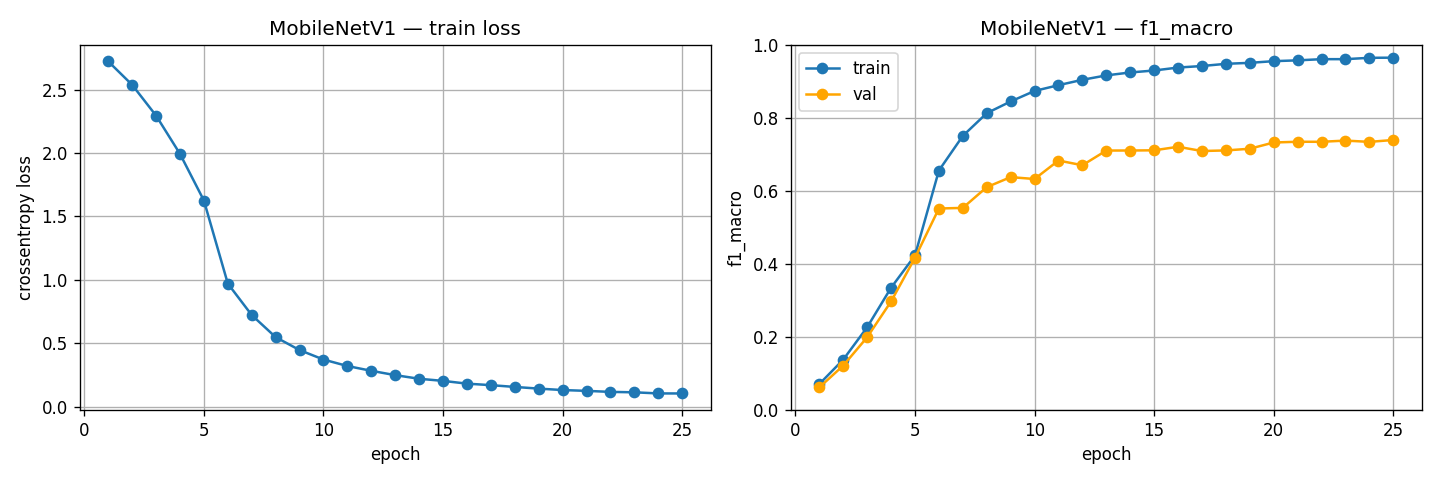

  → output/curves_MobileNetV1.png


In [9]:
mobilenet = MobileNetV1(num_classes=num_classes)
mobilenet, best_val_f1_mob, history_mob = load_or_train(
    mobilenet, train_loader, val_loader,
    device=device, epochs=25, lr=1e-3,
    save_path=str(OUT_DIR / "mobilenet_v1_history.json"),
)
plot_training_curves(history_mob, "MobileNetV1")

mobilenet v1 results on the test set

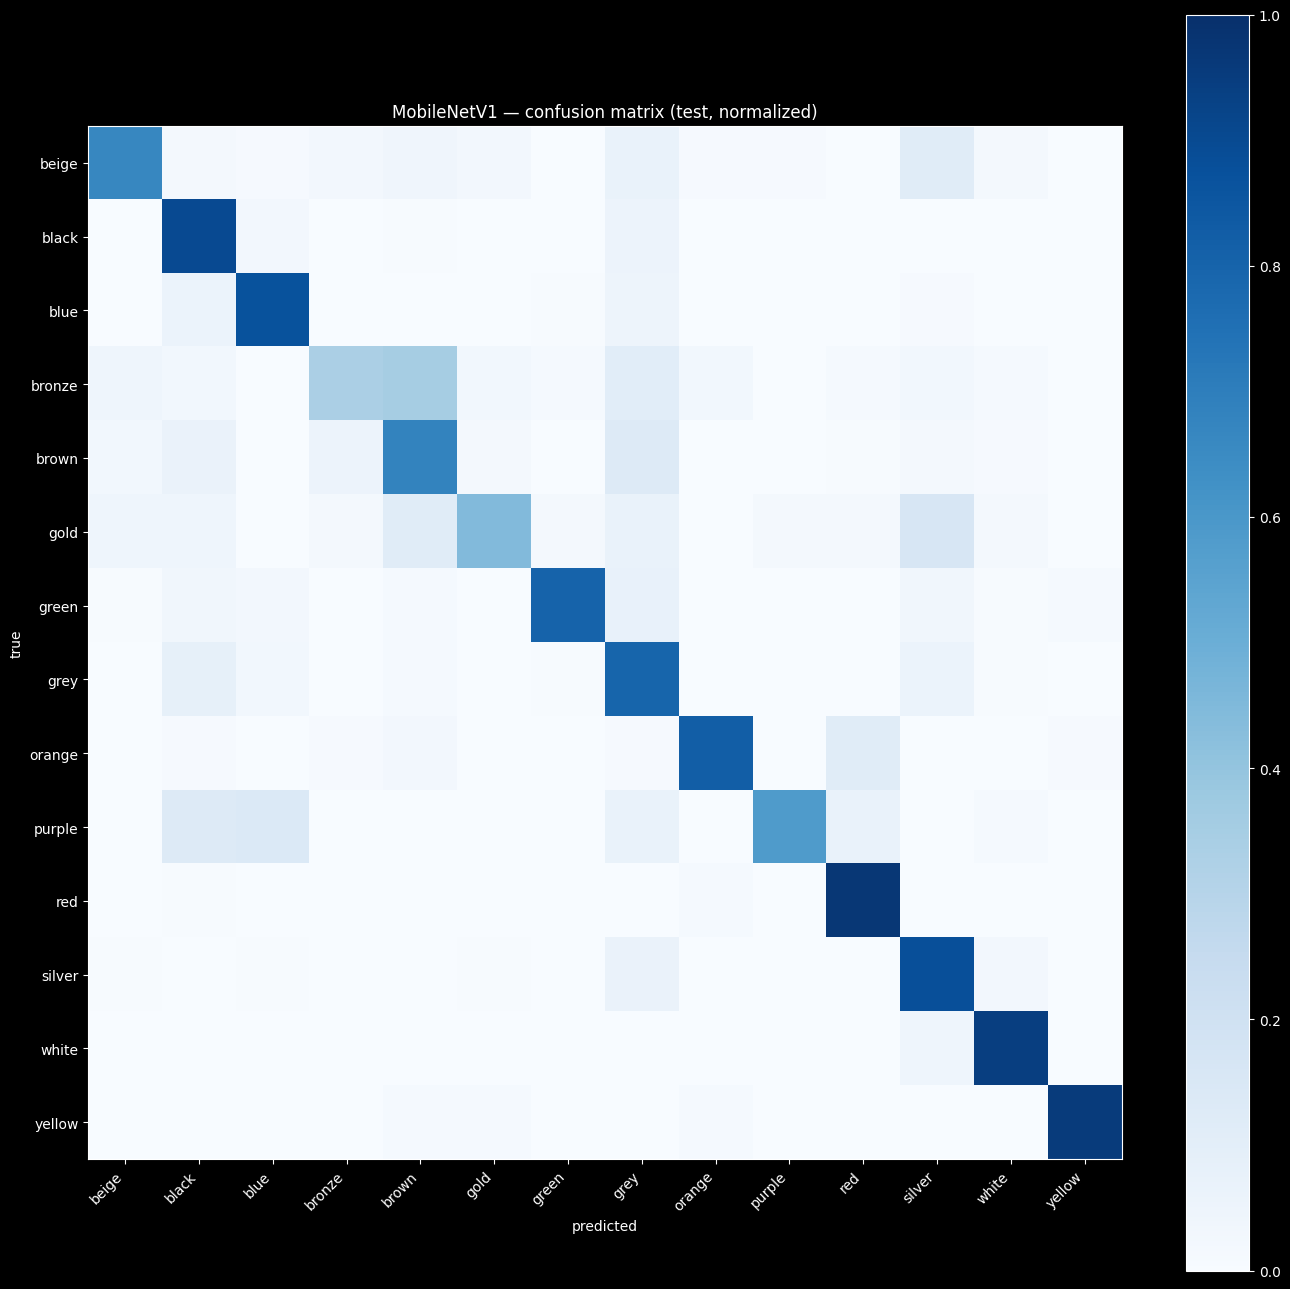

  → output/cm_MobileNetV1.png
              precision    recall  f1-score   support

       beige      0.762     0.667     0.711       120
       black      0.894     0.902     0.898      2864
        blue      0.906     0.871     0.888      1697
      bronze      0.500     0.333     0.400        66
       brown      0.586     0.676     0.628       182
        gold      0.413     0.442     0.427        43
       green      0.817     0.801     0.809       156
        grey      0.784     0.795     0.790      1895
      orange      0.730     0.821     0.773       112
      purple      0.627     0.583     0.604        72
         red      0.978     0.970     0.974      1219
      silver      0.846     0.882     0.864      1554
       white      0.962     0.942     0.952      1879
      yellow      0.977     0.955     0.966       133

    accuracy                          0.877     11992
   macro avg      0.770     0.760     0.763     11992
weighted avg      0.878     0.877     0.877     11

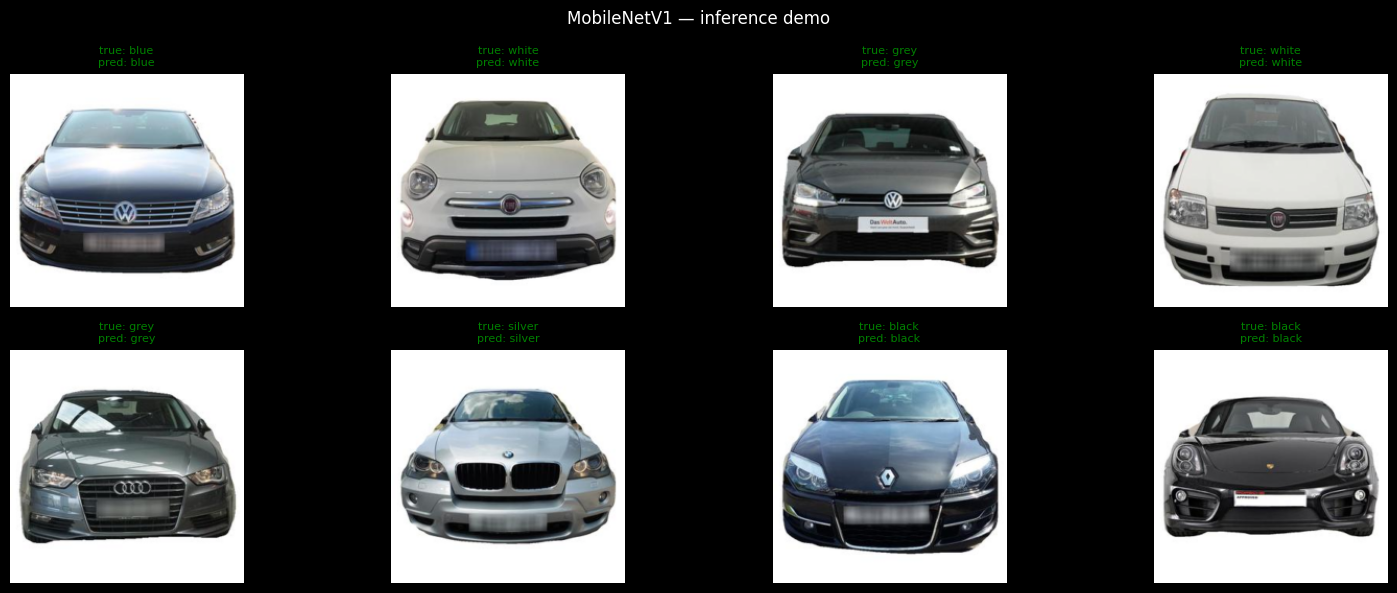

  → output/inference_MobileNetV1.png


In [10]:
test_f1_mob, ys_mob, preds_mob = evaluate(mobilenet, test_loader, device)
plot_confusion_matrix(ys_mob, preds_mob, colors, "MobileNetV1")
save_classification_report(ys_mob, preds_mob, colors, test_f1_mob, "MobileNetV1")
run_inference_demo(mobilenet, test_ds, colors, device, n=8, name="MobileNetV1")

fine-tuning resnet18 on imagenet weights — 10 epochs, lr=1e-4

epochs:   0%|          | 0/10 [05:05<?, ?it/s]

  epoch 01/10 | loss=0.5709 | train_f1=0.8174 | val_f1=0.7000 | lr=9.76e-05


epochs:  10%|█         | 1/10 [10:13<45:56, 306.27s/it]

  epoch 02/10 | loss=0.2345 | train_f1=0.9268 | val_f1=0.7038 | lr=9.05e-05


epochs:  20%|██        | 2/10 [15:16<40:54, 306.79s/it]

...

epochs:  80%|████████  | 8/10 [45:32<10:05, 302.79s/it]

  epoch 09/10 | loss=0.0528 | train_f1=0.9841 | val_f1=0.7978 | lr=2.45e-06


epochs:  90%|█████████ | 9/10 [50:37<05:02, 302.89s/it]

  epoch 10/10 | loss=0.0454 | train_f1=0.9858 | val_f1=0.7952 | lr=0.00e+00


epochs: 100%|██████████| 10/10 [50:37<00:00, 303.77s/it]


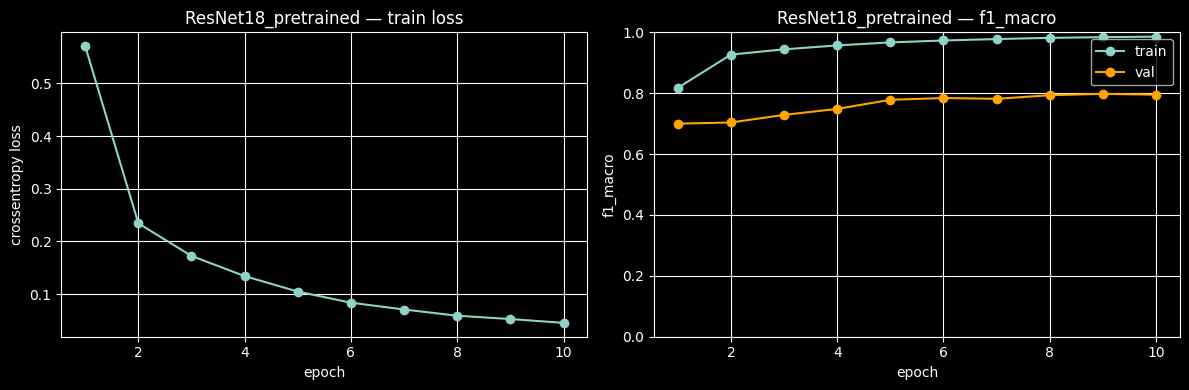

  → output/curves_ResNet18_pretrained.png


In [11]:
resnet18 = make_pretrained_resnet18(num_classes)
resnet18, best_val_f1_res, history_res = load_or_train(
    resnet18, train_loader, val_loader,
    device=device, epochs=10, lr=1e-4,
    save_path=str(OUT_DIR / "resnet18_finetuned_history.json"),
)
plot_training_curves(history_res, "ResNet18_pretrained")

resnet18 results on the test set

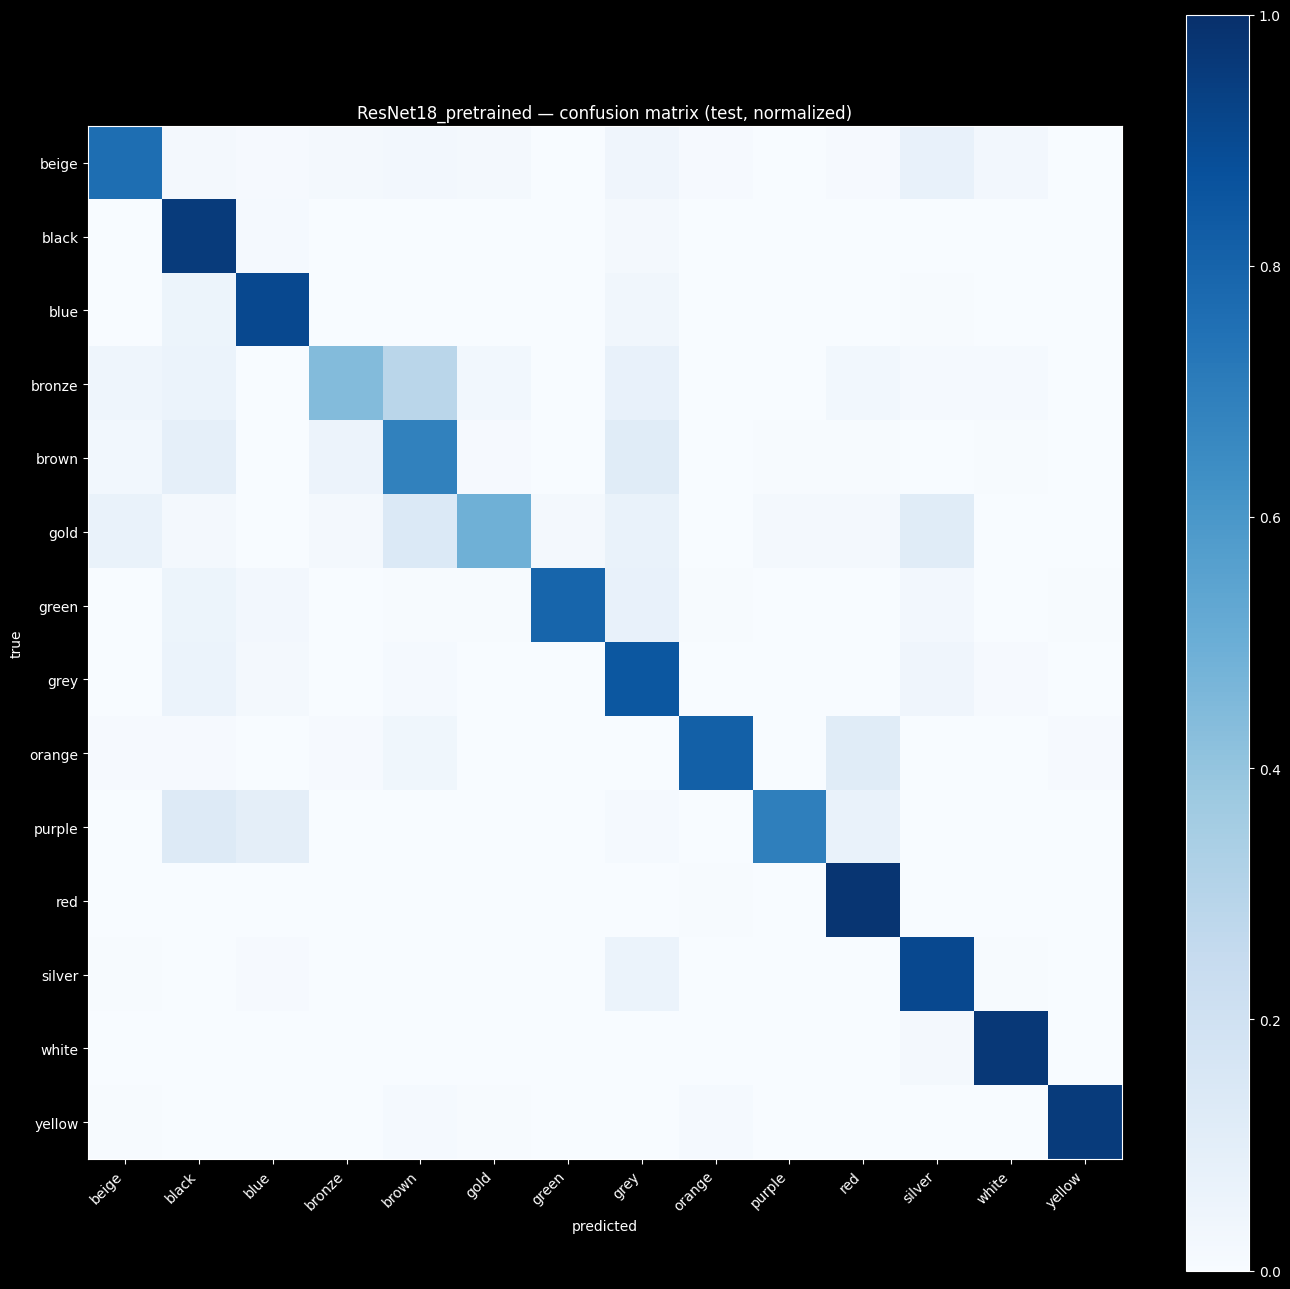

  → output/cm_ResNet18_pretrained.png
              precision    recall  f1-score   support

       beige      0.771     0.758     0.765       120
       black      0.915     0.955     0.934      2864
        blue      0.930     0.905     0.917      1697
      bronze      0.604     0.439     0.509        66
       brown      0.628     0.687     0.656       182
        gold      0.488     0.488     0.488        43
       green      0.925     0.795     0.855       156
        grey      0.859     0.849     0.854      1895
      orange      0.843     0.812     0.827       112
      purple      0.746     0.694     0.719        72
         red      0.974     0.979     0.977      1219
      silver      0.905     0.906     0.906      1554
       white      0.981     0.968     0.974      1879
      yellow      0.984     0.955     0.969       133

    accuracy                          0.914     11992
   macro avg      0.825     0.799     0.811     11992
weighted avg      0.914     0.914     0.91

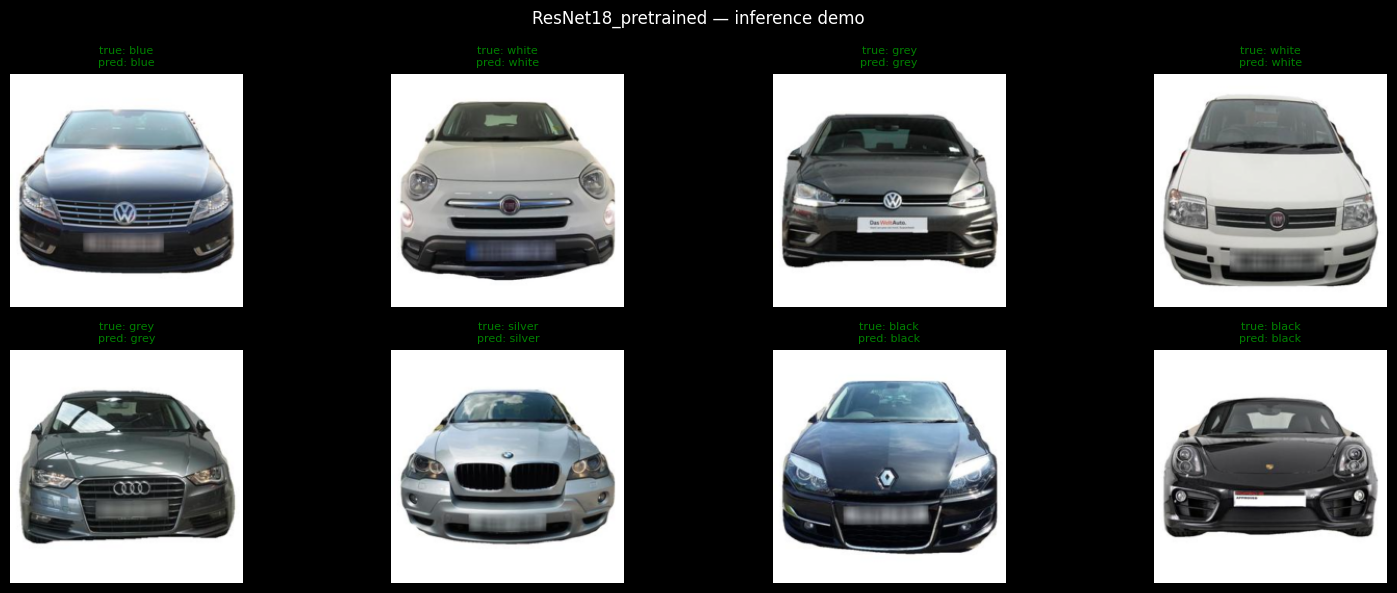

  → output/inference_ResNet18_pretrained.png


In [12]:
test_f1_res, ys_res, preds_res = evaluate(resnet18, test_loader, device)
plot_confusion_matrix(ys_res, preds_res, colors, "ResNet18_pretrained")
save_classification_report(ys_res, preds_res, colors, test_f1_res, "ResNet18_pretrained")
run_inference_demo(resnet18, test_ds, colors, device, n=8, name="ResNet18_pretrained")

fine-tuning efficientnet-b0 on imagenet weights — 10 epochs, lr=1e-4

epochs:   0%|          | 0/10 [08:16<?, ?it/s]

  epoch 01/10 | loss=0.8463 | train_f1=0.7365 | val_f1=0.6856 | lr=9.76e-05


epochs:  10%|█         | 1/10 [16:42<1:14:33, 497.00s/it]

  epoch 02/10 | loss=0.3260 | train_f1=0.8952 | val_f1=0.7507 | lr=9.05e-05


epochs:  20%|██        | 2/10 [25:16<1:06:59, 502.48s/it]

...

epochs:  80%|████████  | 8/10 [1:14:45<16:32, 496.16s/it]

  epoch 09/10 | loss=0.1017 | train_f1=0.9672 | val_f1=0.7984 | lr=2.45e-06


epochs:  90%|█████████ | 9/10 [1:23:21<08:16, 496.85s/it]

  epoch 10/10 | loss=0.0987 | train_f1=0.9687 | val_f1=0.7981 | lr=0.00e+00


epochs: 100%|██████████| 10/10 [1:23:21<00:00, 500.18s/it]


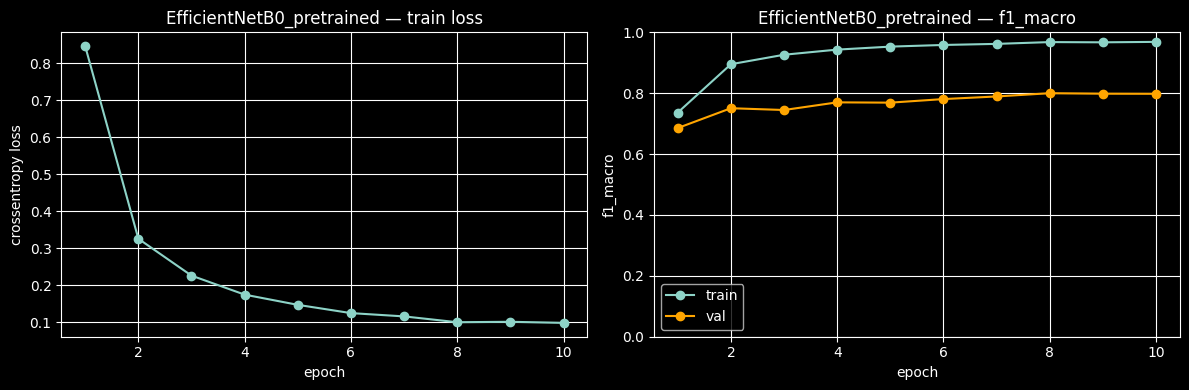

  → output/curves_EfficientNetB0_pretrained.png


In [13]:
effb0 = make_pretrained_efficientnet_b0(num_classes)
effb0, best_val_f1_eff, history_eff = load_or_train(
    effb0, train_loader, val_loader,
    device=device, epochs=10, lr=1e-4,
    save_path=str(OUT_DIR / "efficientnet_b0_finetuned_history.json"),
)
plot_training_curves(history_eff, "EfficientNetB0_pretrained")

efficientnet-b0 results on the test set

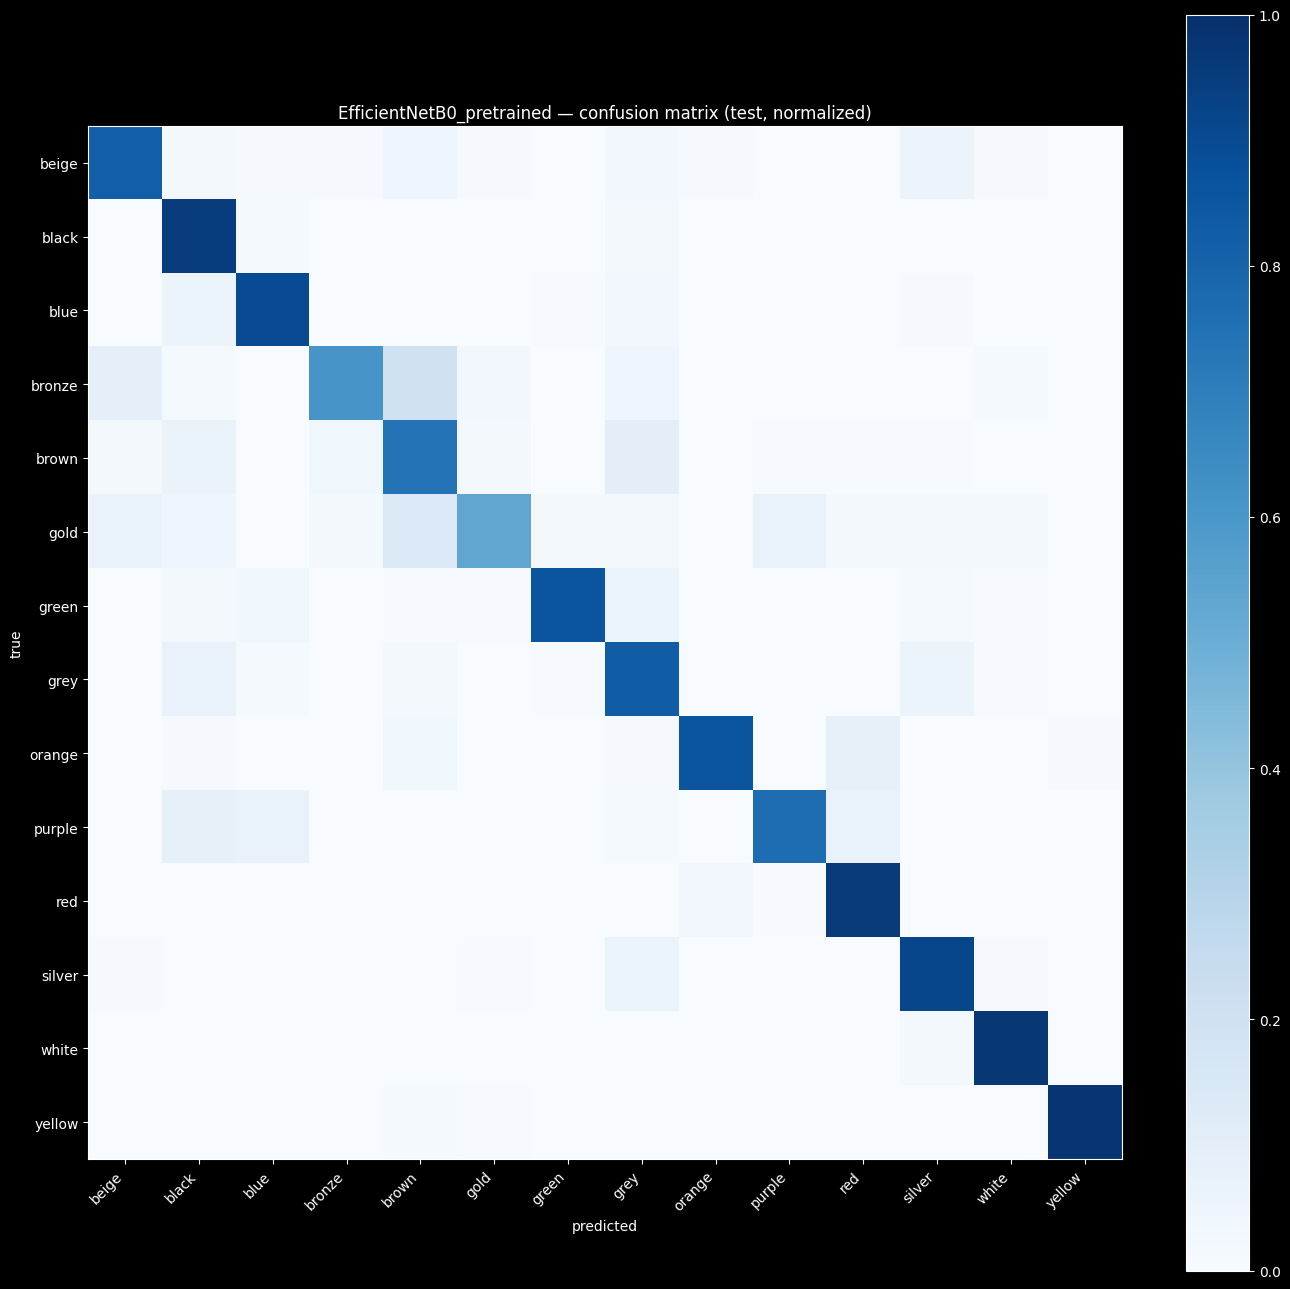

  → output/cm_EfficientNetB0_pretrained.png
              precision    recall  f1-score   support

       beige      0.748     0.817     0.781       120
       black      0.917     0.950     0.933      2864
        blue      0.948     0.894     0.920      1697
      bronze      0.702     0.606     0.650        66
       brown      0.608     0.742     0.668       182
        gold      0.418     0.535     0.469        43
       green      0.838     0.859     0.848       156
        grey      0.867     0.826     0.846      1895
      orange      0.696     0.857     0.768       112
      purple      0.663     0.764     0.710        72
         red      0.977     0.961     0.969      1219
      silver      0.895     0.911     0.903      1554
       white      0.979     0.970     0.975      1879
      yellow      0.992     0.977     0.985       133

    accuracy                          0.911     11992
   macro avg      0.803     0.833     0.816     11992
weighted avg      0.913     0.911   

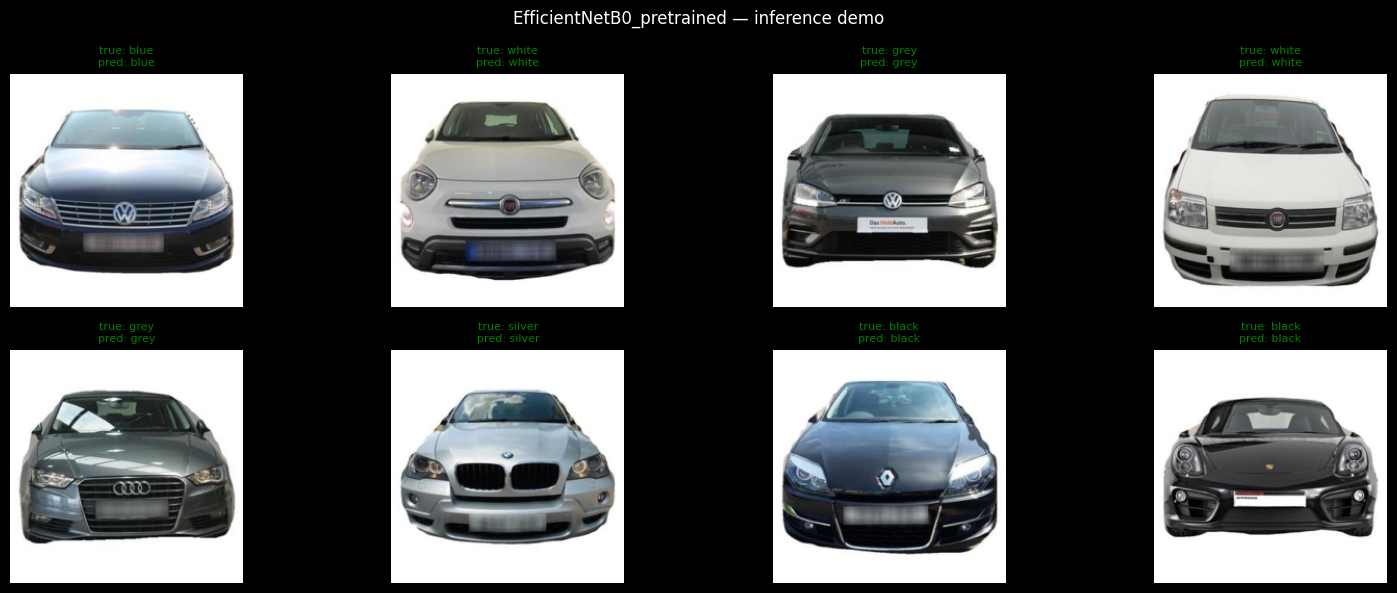

  → output/inference_EfficientNetB0_pretrained.png


In [17]:
test_f1_eff, ys_eff, preds_eff = evaluate(effb0, test_loader, device)
plot_confusion_matrix(ys_eff, preds_eff, colors, "EfficientNetB0_pretrained")
save_classification_report(ys_eff, preds_eff, colors, test_f1_eff, "EfficientNetB0_pretrained")
run_inference_demo(effb0, test_ds, colors, device, n=8, name="EfficientNetB0_pretrained")

final comparison of all three models by test f1_macro

In [16]:
results = {
    "MobileNetV1": test_f1_mob,
    "ResNet18 (pretrained)": test_f1_res,
    "EfficientNet-B0 (pretrained)": test_f1_eff,
}
print("results (test f1_macro):")
for name, f1 in results.items():
    print(f"  {name:<35} {f1:.4f}")
best_model = max(results, key=results.get)
print(f"\nbest model: {best_model}  (f1={results[best_model]:.4f})")
target_ok = max(results.values()) > 0.8
print(f"target f1_macro > 0.80: {'achieved' if target_ok else 'not achieved'}")

summary = {
    "results": {k: round(v, 6) for k, v in results.items()},
    "best_model": best_model,
    "best_f1": round(results[best_model], 6),
    "target_f1_08_achieved": bool(target_ok),
}
summary_path = OUT_DIR / "summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"\n  -> {summary_path}")

results (test f1_macro):
  MobileNetV1                         0.7631
  ResNet18 (pretrained)               0.8108
  EfficientNet-B0 (pretrained)        0.8160

best model: EfficientNet-B0 (pretrained)  (f1=0.8160)
target f1_macro > 0.80: achieved

  -> output/summary.json


## вывод

обучили три модели классификации цвета автомобиля на датасете confirmed_fronts, 59956 изображений, 14 классов после фильтрации редких цветов

датасет очень несбалансирован: black 14317 изображений, gold всего 217. использовали weightedRandomSampler чтобы редкие классы чаще попадали в батч, хотя проблему это полностью не решает: редкие классы всё равно видят меньше уникальных примеров за эпоху

сравнение моделей:

| модель | обучение | эпох | lr | f1_macro |
|---|---|---|---|---|
| mobilenetv1 | с нуля | 25 | 1e-3 | 0.7631 |
| resnet18 | imagenet → finetune | 10 | 1e-4 | 0.8108 |
| efficientnet-b0 | imagenet → finetune | 10 | 1e-4 | 0.8160 |

цель больше 0.80 достигнута, лучший результат у efficientnet-b0

mobilenetv1 с нуля сильно переобучается: train_f1 доходит до 0.96, а val_f1 выходит на плато примерно 0.74. без предобученных весов нормально выучить цветовые признаки не получается

resnet18 и efficientnet-b0 с imagenet-весами сходятся намного быстрее: уже на первой эпохе resnet18 даёт train_f1 примерно 0.82

наиболее сложные классы:

| класс | mobilenetv1 f1 | resnet18 f1 | efficientnet-b0 f1 | причина |
|---|---|---|---|---|
| bronze | 0.40 | 0.51 | 0.65 | мало примеров, похож на beige |
| gold | 0.43 | 0.49 | 0.47 | мало примеров, похож на yellow |

red, white и yellow идут почти идеально, f1 выше 0.96 у предобученных моделей